# 2030 Capacity Expansion: Scenario B1 vs B2

This notebook compares two of the scenarios defined in Chapter 5 (Scenario Framework):

| ID | Name | Solar/Wind WACC | Gas WACC | Gas Price | NDC? |
|---|---|---|---|---|---|
| B1 | Uniform 10% | 10% | 10% | $2.18/MMBtu | No |
| B2 | Hatton | 13.79% | 14.68%* | $2.18/MMBtu | No |

*As run, the config uses **14.86%** for gas, not the 14.68% in the framework
document. This 0.18 point gap should be resolved (fix the config to match the
framework, or update the framework to match the config) before this result is
reported as B2.

This is 2 of the 21 scenarios in the full framework. The WACC sweep (C1-C9),
policy de-risking (P2-P4), decarbonization (D1-D3), gas pricing (P1, P1D) and
transition risk (G1) scenarios are not yet run.

**Currency.** PyPSA-Earth's `output_currency` is EUR, so every cost value read
from the network is in EUR. This notebook converts to USD using the same rate
already embedded in the config's gas price conversion (0.7532 EUR/USD), for
consistency with how the model's own costs were built, rather than pulling a
separate live exchange rate.

In [43]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

# Same rate used in the config to convert the $2.18/MMBtu gas price to EUR.
# Re-used here for consistency rather than sourcing a separate live FX rate.
EUR_PER_USD = 0.7532
USD_PER_EUR = 1 / EUR_PER_USD

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

## 1. Load both networks

A = B1, uniform 10% WACC.
B = B2, Hatton differentiated WACC.

In [44]:
A = pypsa.Network("/Users/fowfloi/Documents/pypsa-earth/results/cap_exp_2030/networks/elec_s_10_ec_lcopt_1h.nc")
B = pypsa.Network("/Users/fowfloi/Documents/pypsa-earth/results/cap_exp_2030_split_wacc/networks/elec_s_10_ec_lcopt_1h.nc")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, lines, line_types, loads, storage_units


## 2. Verify the two runs are comparable

Every result below is only valid if A and B differ solely in the discount
rate. This checks demand, resolution, weather year and the VOLL assumption
all match. If any line differs, stop here and fix the configs before
reading further.

In [45]:
for name, n in [("A (B1 uniform)", A), ("B (B2 Hatton)", B)]:
    w = n.snapshot_weightings.objective
    d = n.loads_t.p_set.sum(axis=1).mul(w).sum() / 1e6
    print(f"{name}: {len(n.snapshots)} snapshots, demand {d:.2f} TWh, "
          f"scale {n.meta['load_options']['scale']}, "
          f"weather {n.meta['load_options']['weather_year']}, "
          f"load_shedding {n.meta['solving']['options']['load_shedding']} EUR/kWh")

A (B1 uniform): 8784 snapshots, demand 77.78 TWh, scale 2.074, weather 2024, load_shedding 0.32 EUR/kWh
B (B2 Hatton): 8784 snapshots, demand 77.78 TWh, scale 2.074, weather 2024, load_shedding 0.32 EUR/kWh


## 3. Isolate the connected grid

The OSM-derived network contains buses with no transmission line to the
rest of the grid (confirmed during 2024 validation). Any capacity the
optimizer places there cannot be delivered anywhere and must be excluded
before any build, siting or cost figure is read.

In [46]:
def get_connected(n):
    n.determine_network_topology()
    main_sub = n.buses.sub_network.mode()[0]
    return n.buses.index[n.buses.sub_network == main_sub].tolist()

conn_A = get_connected(A)
conn_B = get_connected(B)
print("A excluded buses:", [b for b in A.buses.index if b not in conn_A])
print("B excluded buses:", [b for b in B.buses.index if b not in conn_B])

A excluded buses: ['NG1 0', 'NG2 0']
B excluded buses: ['NG1 0', 'NG2 0']


## 4. What got built, by technology

Existing capacity, optimal capacity and new build for each carrier,
restricted to the connected grid, side by side for both scenarios.
Changinf the WACC from the 10% which is typically applied in existing studies to an 
empirically estimated WACC did not materially change what the model is building but it did increase how much solar is built relative to OCGT. Perhaps do a scenario to test when the WACC rate reflects real market humbers.

In [47]:
def build_summary(n, connected, label):
    gens = n.generators[n.generators.bus.isin(connected)]
    df = pd.DataFrame({
        "existing_GW": gens.p_nom / 1e3,
        "optimal_GW": gens.p_nom_opt / 1e3,
        "carrier": gens.carrier,
    })
    df["new_GW"] = df.optimal_GW - df.existing_GW
    out = df.groupby("carrier")[["existing_GW", "optimal_GW", "new_GW"]].sum()
    out.columns = pd.MultiIndex.from_product([[label], out.columns])
    return out

comp = pd.concat([
    build_summary(A, conn_A, "A (B1)"),
    build_summary(B, conn_B, "B (B2)"),
], axis=1).fillna(0)

print(comp.round(2).to_string())

                   A (B1)                        B (B2)                  
              existing_GW optimal_GW new_GW existing_GW optimal_GW new_GW
carrier                                                                  
CCGT                 3.44       3.44   0.00        3.44       3.44   0.00
OCGT                 8.74      23.52  14.78        8.74      27.83  19.09
load shedding       12.01      12.01   0.00       12.01      12.01   0.00
onwind               0.00       0.00   0.00        0.00       0.00   0.00
solar                0.16       4.53   4.36        0.16       3.75   3.59


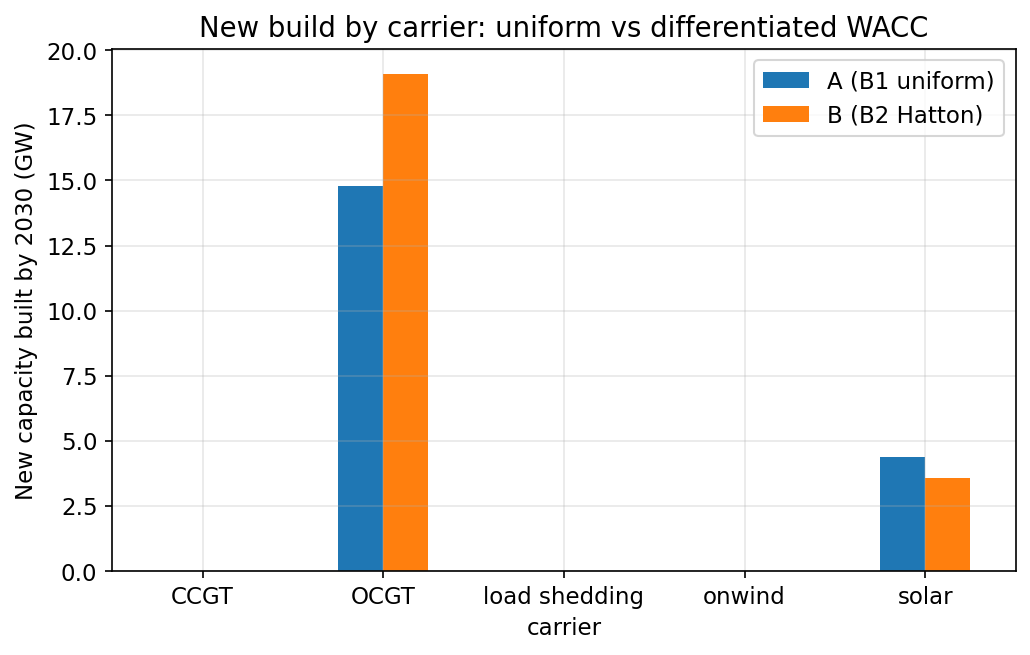

In [48]:
# Visual: new build by carrier, A vs B
new_build = pd.DataFrame({
    "A (B1 uniform)": comp[("A (B1)", "new_GW")],
    "B (B2 Hatton)": comp[("B (B2)", "new_GW")],
})
fig, ax = plt.subplots(figsize=(7, 4.5))
new_build.plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("New capacity built by 2030 (GW)")
ax.set_title("New build by carrier: uniform vs differentiated WACC")
plt.tight_layout()
plt.savefig("fig_2030_new_build_A_vs_B.png", bbox_inches="tight")
plt.show()

## 5. Where it got built

In the NIRP, north is the solar dependent while the south remains gas-dependent. From my model, that conclusion also holds true as we 
see resource gradiation across the North and south own conclusion was that the north becomes Nigeria's solar
powerhouse while the south stays gas-dependent. This checks whether the
model reproduces that pattern, and whether differentiated financing
shifts siting even where it doesn't shift the national technology mix.

In [49]:
def siting(n, connected, label):
    gens = n.generators[n.generators.bus.isin(connected)]
    new = (gens.p_nom_opt - gens.p_nom).clip(lower=0)
    lat = n.buses.loc[gens.bus, "y"].values
    band = pd.Series(["north" if l >= 9 else "south" for l in lat], index=gens.index)
    s = new.groupby([band, gens.carrier]).sum().div(1e3)
    s.name = label
    return s

sit = pd.concat([
    siting(A, conn_A, "A (B1) GW"),
    siting(B, conn_B, "B (B2) GW"),
], axis=1).fillna(0)

print(sit.round(2).to_string())

                     A (B1) GW  B (B2) GW
      carrier                            
north OCGT                1.19       5.12
      load shedding       0.00       0.00
      onwind              0.00       0.00
      solar               4.49       3.74
south CCGT                0.00       0.00
      OCGT               13.59      13.98
      load shedding       0.00       0.00
      onwind              0.00       0.00
      solar               0.00       0.00


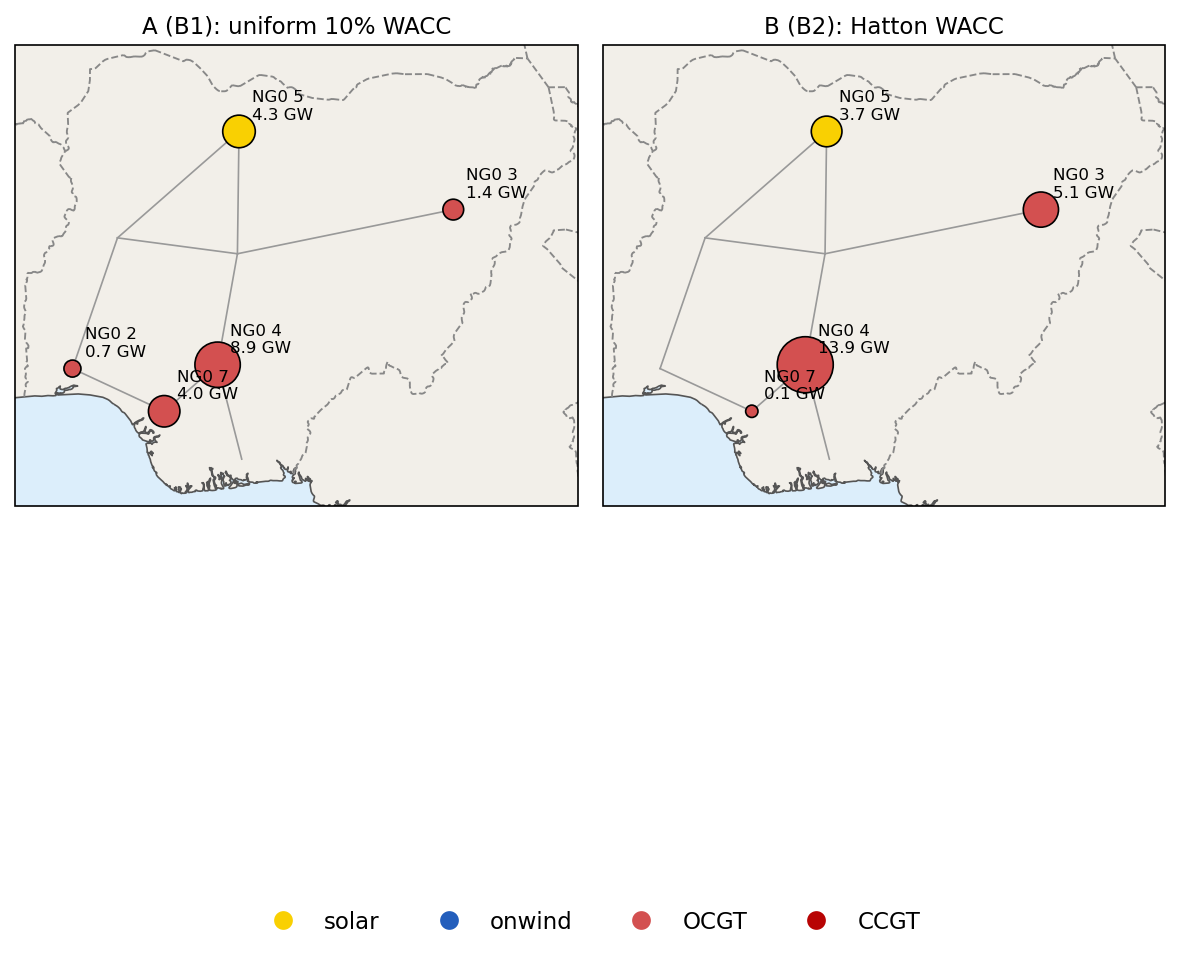

In [50]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

MIN_MW = 10  # drops optimizer rounding noise, not real new capacity

def new_build_by_bus(n, connected):
    gens = n.generators[n.generators.bus.isin(connected)]
    new = (gens.p_nom_opt - gens.p_nom).clip(lower=0)
    new = new[new > MIN_MW]
    by_bus_carrier = new.groupby([gens.bus, gens.carrier]).sum()
    total = by_bus_carrier.groupby(level=0).sum()
    dominant = by_bus_carrier.groupby(level=0).idxmax().apply(lambda x: x[1])
    return total, dominant

tech_colors = {"solar": "#f9d002", "onwind": "#235ebc",
               "OCGT": "#d35050", "CCGT": "#b80404"}

def plot_build_map(n, connected, title, ax):
    total, dominant = new_build_by_bus(n, connected)
    coords = n.buses.loc[total.index, ["x", "y"]]

    ax.set_extent([2.5, 14.7, 4.0, 14.0], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="#f2efe9", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="#dceefb", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="#555555")
    ax.add_feature(cfeature.BORDERS, linewidth=0.9, linestyle="--", edgecolor="#888888")

    for _, ln in n.lines.iterrows():
        b0, b1 = n.buses.loc[ln.bus0], n.buses.loc[ln.bus1]
        ax.plot([b0.x, b1.x], [b0.y, b1.y], color="#999999", lw=0.8,
                transform=ccrs.PlateCarree(), zorder=1)

    colors = dominant.map(tech_colors)
    ax.scatter(coords.x, coords.y, s=30 + total.values / 20,
              c=colors, edgecolor="black", linewidth=0.8,
              transform=ccrs.PlateCarree(), zorder=3)

    for bus in total.index:
        ax.annotate(f"{bus}\n{total[bus]/1e3:.1f} GW",
                    (coords.at[bus, "x"], coords.at[bus, "y"]),
                    textcoords="offset points", xytext=(6, 6),
                    fontsize=8, transform=ccrs.PlateCarree())

    ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(8, 9), subplot_kw={"projection": ccrs.PlateCarree()})
plot_build_map(A, conn_A, "A (B1): uniform 10% WACC", axes[0])
plot_build_map(B, conn_B, "B (B2): Hatton WACC", axes[1])

handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
                      markersize=10, label=t) for t, c in tech_colors.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False)
plt.tight_layout()
plt.savefig("fig_2030_build_map_A_vs_B.png", bbox_inches="tight")
plt.show()

## 6. Cost decomposition, in USD

All figures are converted from the model's native EUR to USD using the
0.7532 EUR/USD.

In [51]:
def cost_breakdown(n, connected, label):
    gens = n.generators[n.generators.bus.isin(connected)]
    w = n.snapshot_weightings.objective

    new_cap = (gens.p_nom_opt - gens.p_nom).clip(lower=0)
    capex_eur = (new_cap * gens.capital_cost).sum()
    opex_eur = (n.generators_t.p[gens.index].mul(w, axis=0) * gens.marginal_cost).sum().sum()

    lines_new = (n.lines.s_nom_opt - n.lines.s_nom).clip(lower=0)
    line_capex_eur = (lines_new * n.lines.capital_cost).sum()

    ls = gens[gens.carrier == "load shedding"]
    shed_twh = (n.generators_t.p[ls.index].mul(w, axis=0).sum().sum() / 1e6
                if len(ls) else 0)

    capex_usd = capex_eur * USD_PER_EUR
    opex_usd = opex_eur * USD_PER_EUR
    line_capex_usd = line_capex_eur * USD_PER_EUR

    print(f"\n=== {label} ===")
    print(f"Generation capex   : ${capex_usd:,.0f}")
    print(f"Generation opex    : ${opex_usd:,.0f}")
    print(f"Transmission capex : ${line_capex_usd:,.0f}")
    print(f"Total              : ${capex_usd + opex_usd + line_capex_usd:,.0f}")
    print(f"Unserved energy    : {shed_twh:.3f} TWh")

    return {"capex": capex_usd, "opex": opex_usd, "line_capex": line_capex_usd,
            "shed_twh": shed_twh}

res_A = cost_breakdown(A, conn_A, "A (B1 uniform)")
res_B = cost_breakdown(B, conn_B, "B (B2 Hatton)")

delta_capex = res_B["capex"] - res_A["capex"]
print(f"\nGeneration capex difference (B - A): ${delta_capex:,.0f}  "
      f"({delta_capex / res_A['capex'] * 100:.1f}%)")


=== A (B1 uniform) ===
Generation capex   : $1,475,117,866
Generation opex    : $1,261,107,782
Transmission capex : $1,575,114
Total              : $2,737,800,762
Unserved energy    : 0.124 TWh

=== B (B2 Hatton) ===
Generation capex   : $2,321,303,036
Generation opex    : $1,291,620,479
Transmission capex : $4,912,521
Total              : $3,617,836,035
Unserved energy    : 0.001 TWh

Generation capex difference (B - A): $846,185,170  (57.4%)


## 7. Summary: did financing differentiation change the mix, or just the cost?

In [52]:
carriers_shift = comp.xs("new_GW", axis=1, level=1).copy()
carriers_shift.columns = ["A (B1)", "B (B2)"]
carriers_shift["pct_change"] = (
    (carriers_shift["B (B2)"] - carriers_shift["A (B1)"])
    / carriers_shift["A (B1)"].replace(0, pd.NA) * 100
)
print(carriers_shift.round(1).to_string())

print(
    f"\nDifferentiated WACC (B2 vs B1) changed generation capex by "
    f"{(res_B['capex'] - res_A['capex']) / res_A['capex'] * 100:.1f}%."
)
if "OCGT" in carriers_shift.index:
    print(f"OCGT new build changed by {carriers_shift.loc['OCGT', 'pct_change']:.1f}%.")
if "solar" in carriers_shift.index:
    print(f"Solar new build changed by {carriers_shift.loc['solar', 'pct_change']:.1f}%.")

               A (B1)  B (B2)  pct_change
carrier                                  
CCGT              0.0     0.0    52.89213
OCGT             14.8    19.1   29.144492
load shedding     0.0     0.0        <NA>
onwind            0.0     0.0  675.316871
solar             4.4     3.6  -17.701364

Differentiated WACC (B2 vs B1) changed generation capex by 57.4%.
OCGT new build changed by 29.1%.
Solar new build changed by -17.7%.
